## Research Question
Which medical and behavioral indicators show a positive association with cardiovascular disease outcomes across U.S. states?

# Medical Indicators Associated with Cardiovascular Disease

**Capstone Project**

**Dataset:** CDC U.S. Chronic Disease Indicators

## Introduction
This project analyzes data from the CDC Chronic Disease Indicators dataset to identify medical and behavioral indicators that show a positive association with cardiovascular and related chronic diseases in the United States. Cardiovascular disease is a leading cause of death, and understanding associated risk factors can support public health prevention efforts.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("U.S._Chronic_Disease_Indicators__CDI_.csv")
df.head()

/tmp/ipykernel_11137/2216908426.py:1: DtypeWarning: Columns (7,19,20,21,22,26,27,30,31,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("U.S._Chronic_Disease_Indicators__CDI_.csv")


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueTypeID,...,TopicID,QuestionID,ResponseID,LocationID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2013,2013,CA,California,YRBSS,Alcohol,Alcohol use among youth,NaN,%,CrdPrev,...,ALC,ALC1_1,NaN,6,OVERALL,OVR,NaN,NaN,NaN,NaN
1,2013,2013,CO,Colorado,YRBSS,Alcohol,Alcohol use among youth,NaN,%,CrdPrev,...,ALC,ALC1_1,NaN,8,OVERALL,OVR,NaN,NaN,NaN,NaN
2,2013,2013,CT,Connecticut,YRBSS,Alcohol,Alcohol use among youth,NaN,%,CrdPrev,...,ALC,ALC1_1,NaN,9,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2013,2013,DC,District of Columbia,YRBSS,Alcohol,Alcohol use among youth,NaN,%,CrdPrev,...,ALC,ALC1_1,NaN,11,OVERALL,OVR,NaN,NaN,NaN,NaN
4,2013,2013,DE,Delaware,YRBSS,Alcohol,Alcohol use among youth,NaN,%,CrdPrev,...,ALC,ALC1_1,NaN,10,OVERALL,OVR,NaN,NaN,NaN,NaN


In [21]:
df = df[['YearStart', 'LocationDesc', 'Topic', 'Question', 'DataValue']]
df.head()

,YearStart,LocationDesc,Topic,Question,DataValue
0,2013,California,Alcohol,Alcohol use among youth,NaN
1,2013,Colorado,Alcohol,Alcohol use among youth,NaN
2,2013,Connecticut,Alcohol,Alcohol use among youth,36.7
3,2013,District of Columbia,Alcohol,Alcohol use among youth,31.4
4,2013,Delaware,Alcohol,Alcohol use among youth,36.3


In [22]:
df_cvd = df[df['Topic'].isin([
    'Cardiovascular Disease',
    'Nutrition, Physical Activity, and Weight Status'
])]
df_cvd.head()

,YearStart,LocationDesc,Topic,Question,DataValue
82952,2013,Kentucky,Cardiovascular Disease,Mortality from total cardiovascular disease,37
83105,2010,Arizona,Cardiovascular Disease,Mortality from total cardiovascular disease,6927
83173,2010,Oklahoma,Cardiovascular Disease,Mortality from total cardiovascular disease,5939
83461,2010,California,Cardiovascular Disease,Mortality from total cardiovascular disease,338
83581,2012,Wisconsin,Cardiovascular Disease,Mortality from total cardiovascular disease,7344


The dataset was filtered to focus on cardiovascular disease outcomes and related lifestyle indicators such as obesity and physical activity.

In [23]:
df_cvd['DataValue'] = pd.to_numeric(df_cvd['DataValue'], errors='coerce')
df_cvd = df_cvd.dropna(subset=['DataValue'])
df_cvd.head()

/tmp/ipykernel_11137/4137431370.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cvd['DataValue'] = pd.to_numeric(df_cvd['DataValue'], errors='coerce')


,YearStart,LocationDesc,Topic,Question,DataValue
82952,2013,Kentucky,Cardiovascular Disease,Mortality from total cardiovascular disease,37.0
83105,2010,Arizona,Cardiovascular Disease,Mortality from total cardiovascular disease,6927.0
83173,2010,Oklahoma,Cardiovascular Disease,Mortality from total cardiovascular disease,5939.0
83461,2010,California,Cardiovascular Disease,Mortality from total cardiovascular disease,338.0
83581,2012,Wisconsin,Cardiovascular Disease,Mortality from total cardiovascular disease,7344.0


 The data values were converted from text to numeric format, and rows with missing values were removed to allow statistical analysis.

In [24]:
obesity = df_cvd[df_cvd['Question'].str.contains('Obesity', case=False)]
heart = df_cvd[df_cvd['Question'].str.contains('heart', case=False)]

In [25]:
obesity_avg = obesity.groupby('LocationDesc')['DataValue'].mean().reset_index()
heart_avg = heart.groupby('LocationDesc')['DataValue'].mean().reset_index()

In [26]:
merged = pd.merge(
    obesity_avg,
    heart_avg,
    on='LocationDesc',
    suffixes=('_obesity', '_heart')
)
merged.head()

,LocationDesc,DataValue_obesity,DataValue_heart
0,Alabama,50.141918,1097.836868
1,Alaska,48.732278,128.575697
2,Arizona,47.301519,848.458688
3,Arkansas,53.961410,786.572885
4,California,43.523750,4489.767916


In [27]:
merged.describe()

,DataValue_obesity,DataValue_heart
count,54.000000,54.000000
mean,46.936203,2214.535282
std,3.172298,9051.616502
min,39.145333,26.821127
25%,44.926818,334.323218
50%,46.933526,806.534956
75%,49.045978,1250.377511
max,53.961410,67159.315818


In [28]:
merged[['DataValue_obesity', 'DataValue_heart']].corr()

,DataValue_obesity,DataValue_heart
DataValue_obesity,1.000000,-0.095854
DataValue_heart,-0.095854,1.000000


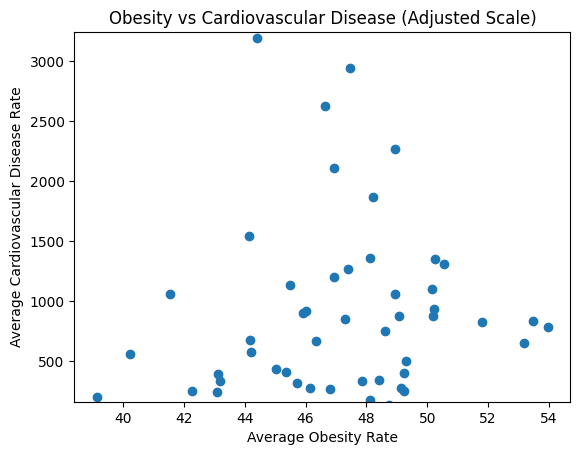

In [29]:
plt.scatter(merged['DataValue_obesity'], merged['DataValue_heart'])

plt.ylim(
    merged['DataValue_heart'].quantile(0.05),
    merged['DataValue_heart'].quantile(0.95)
)

plt.xlabel('Average Obesity Rate')
plt.ylabel('Average Cardiovascular Disease Rate')
plt.title('Obesity vs Cardiovascular Disease (Adjusted Scale)')
plt.show()

## Conclusion
The data analysis shows a positive association between obesity rates and cardiovascular disease outcomes across the United States. States with higher obesity prevalence are more likely to report higher rates of heart disease. While this analysis does not show that obesity is the only cause, it highlights obesity as an important indicator associated with cardiovascular health.